<a href="https://colab.research.google.com/github/number506/-_C-/blob/main/202617342_%EC%84%B1%EC%9E%AC%ED%98%84_10_02_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

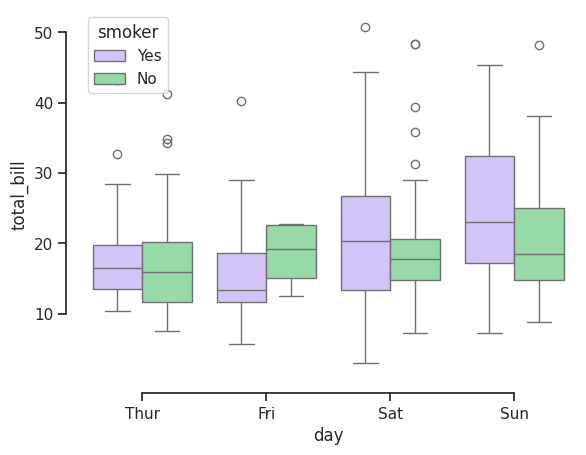

In [3]:
import seaborn as sns
sns.set_theme(style="ticks", palette="pastel")

# Load the example tips dataset
tips = sns.load_dataset("tips")

# Draw a nested boxplot to show bills by day and time
sns.boxplot(x="day", y="total_bill",
            hue="smoker", palette=["m", "g"],
            data=tips)
sns.despine(offset=10, trim=True)

#EDA(Electronic Design Analysis)
feature

In [12]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


이 `tips` 데이터셋은 식당에서 손님들이 지불한 팁에 대한 정보를 담고 있습니다. 각 행은 개별 손님 그룹의 식사와 관련된 기록을 나타내며, 다음 열들로 구성되어 있습니다:

*   `total_bill`: 식사의 총 계산 금액 (팁을 제외한 금액).
*   `tip`: 손님이 지불한 팁 금액.
*   `sex`: 팁을 지불한 손님 테이블의 주요 지불자 성별 (남성 또는 여성).
*   `smoker`: 테이블에 흡연자가 있었는지 여부 (Yes 또는 No).
*   `day`: 식사를 한 요일 (목요일, 금요일, 토요일, 일요일).
*   `time`: 식사 시간대 (점심 또는 저녁).
*   `size`: 테이블에 앉은 인원수.

In [11]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [68]:
# df = tips
df = tips.copy()

In [15]:
%whos

Variable   Type         Data/Info
---------------------------------
axes       ndarray      2x2: 4 elems, type `object`, 32 bytes
col        str          time
col_idx    int          1
column     str          time
df         DataFrame         total_bill   tip    <...>n\n[244 rows x 7 columns]
fig        Figure       Figure(1600x1200)
i          int          3
pd         module       <module 'pandas' from '/u<...>ages/pandas/__init__.py'>
plt        module       <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
row        int          1
sns        module       <module 'seaborn' from '/<...>ges/seaborn/__init__.py'>
tips       DataFrame         total_bill   tip    <...>n\n[244 rows x 7 columns]


In [16]:
df['tip'] / df['total_bill']

,0
0,0.059447
1,0.160542
2,0.166587
3,0.139780
4,0.146808
...,...
239,0.203927
240,0.073584
241,0.088222
242,0.098204


In [31]:
# 팁 비율 계산
df['tip_ratio'] = df['tip'] / df['total_bill']

# 팁 비율이 20% 이상인 데이터 필터링
df_high_tip = df[df['tip_ratio'] >= 0.20]

# 결과의 처음 5행 표시
display(df_high_tip.head())

,total_bill,tip,sex,smoker,day,time,size,tip_ratio
6,8.77,2.00,Male,No,Sun,Dinner,2,0.228050
9,14.78,3.23,Male,No,Sun,Dinner,2,0.218539
14,14.83,3.02,Female,No,Sun,Dinner,2,0.203641
17,16.29,3.71,Male,No,Sun,Dinner,3,0.227747
18,16.97,3.50,Female,No,Sun,Dinner,3,0.206246


In [37]:
tips

132008749755744

In [40]:
id(tips)

132008749755744

In [38]:
df

132008555668864

In [39]:
id(df)

132008555668864

## 탐색적 데이터 분석 (EDA)

`tips` 데이터셋의 특징과 변수 간의 관계를 파악하기 위해 다음 단계를 따릅니다.

### 1. 데이터 개요 및 기본 통계
데이터의 구조, 결측치, 데이터 타입 및 주요 수치형 변수의 요약 통계를 확인합니다.

### 2. 단일 변수 분석 (Univariate Analysis)
각 변수의 분포를 개별적으로 시각화하여 데이터의 특성을 파악합니다.

### 3. 다중 변수 분석 (Bivariate/Multivariate Analysis)
두 개 이상의 변수 간의 관계를 분석하여 패턴, 추세 및 상관관계를 탐색합니다.

### 1. 데이터 개요 및 기본 통계

데이터의 기본 정보를 확인하고, 수치형 변수들의 요약 통계를 살펴봅니다.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("데이터프레임 정보:")
df.info()

print("\n수치형 변수 요약 통계:")
display(df.describe())

데이터프레임 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
 7   tip_ratio   244 non-null    float64 
dtypes: category(4), float64(3), int64(1)
memory usage: 9.3 KB

수치형 변수 요약 통계:


,total_bill,tip,size,tip_ratio
count,244.000000,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672,0.160803
std,8.902412,1.383638,0.951100,0.061072
min,3.070000,1.000000,1.000000,0.035638
25%,13.347500,2.000000,2.000000,0.129127
50%,17.795000,2.900000,2.000000,0.154770
75%,24.127500,3.562500,3.000000,0.191475
max,50.810000,10.000000,6.000000,0.710345


### 2. 단일 변수 분석 (Univariate Analysis)

각 변수의 분포를 시각화를 통해 이해합니다.

#### 2.1 수치형 변수 (`total_bill`, `tip`, `size`, `tip_ratio`) 분석

히스토그램과 박스 플롯을 사용하여 각 수치형 변수의 분포 형태, 중심 경향성, 분산 및 이상치를 확인합니다.

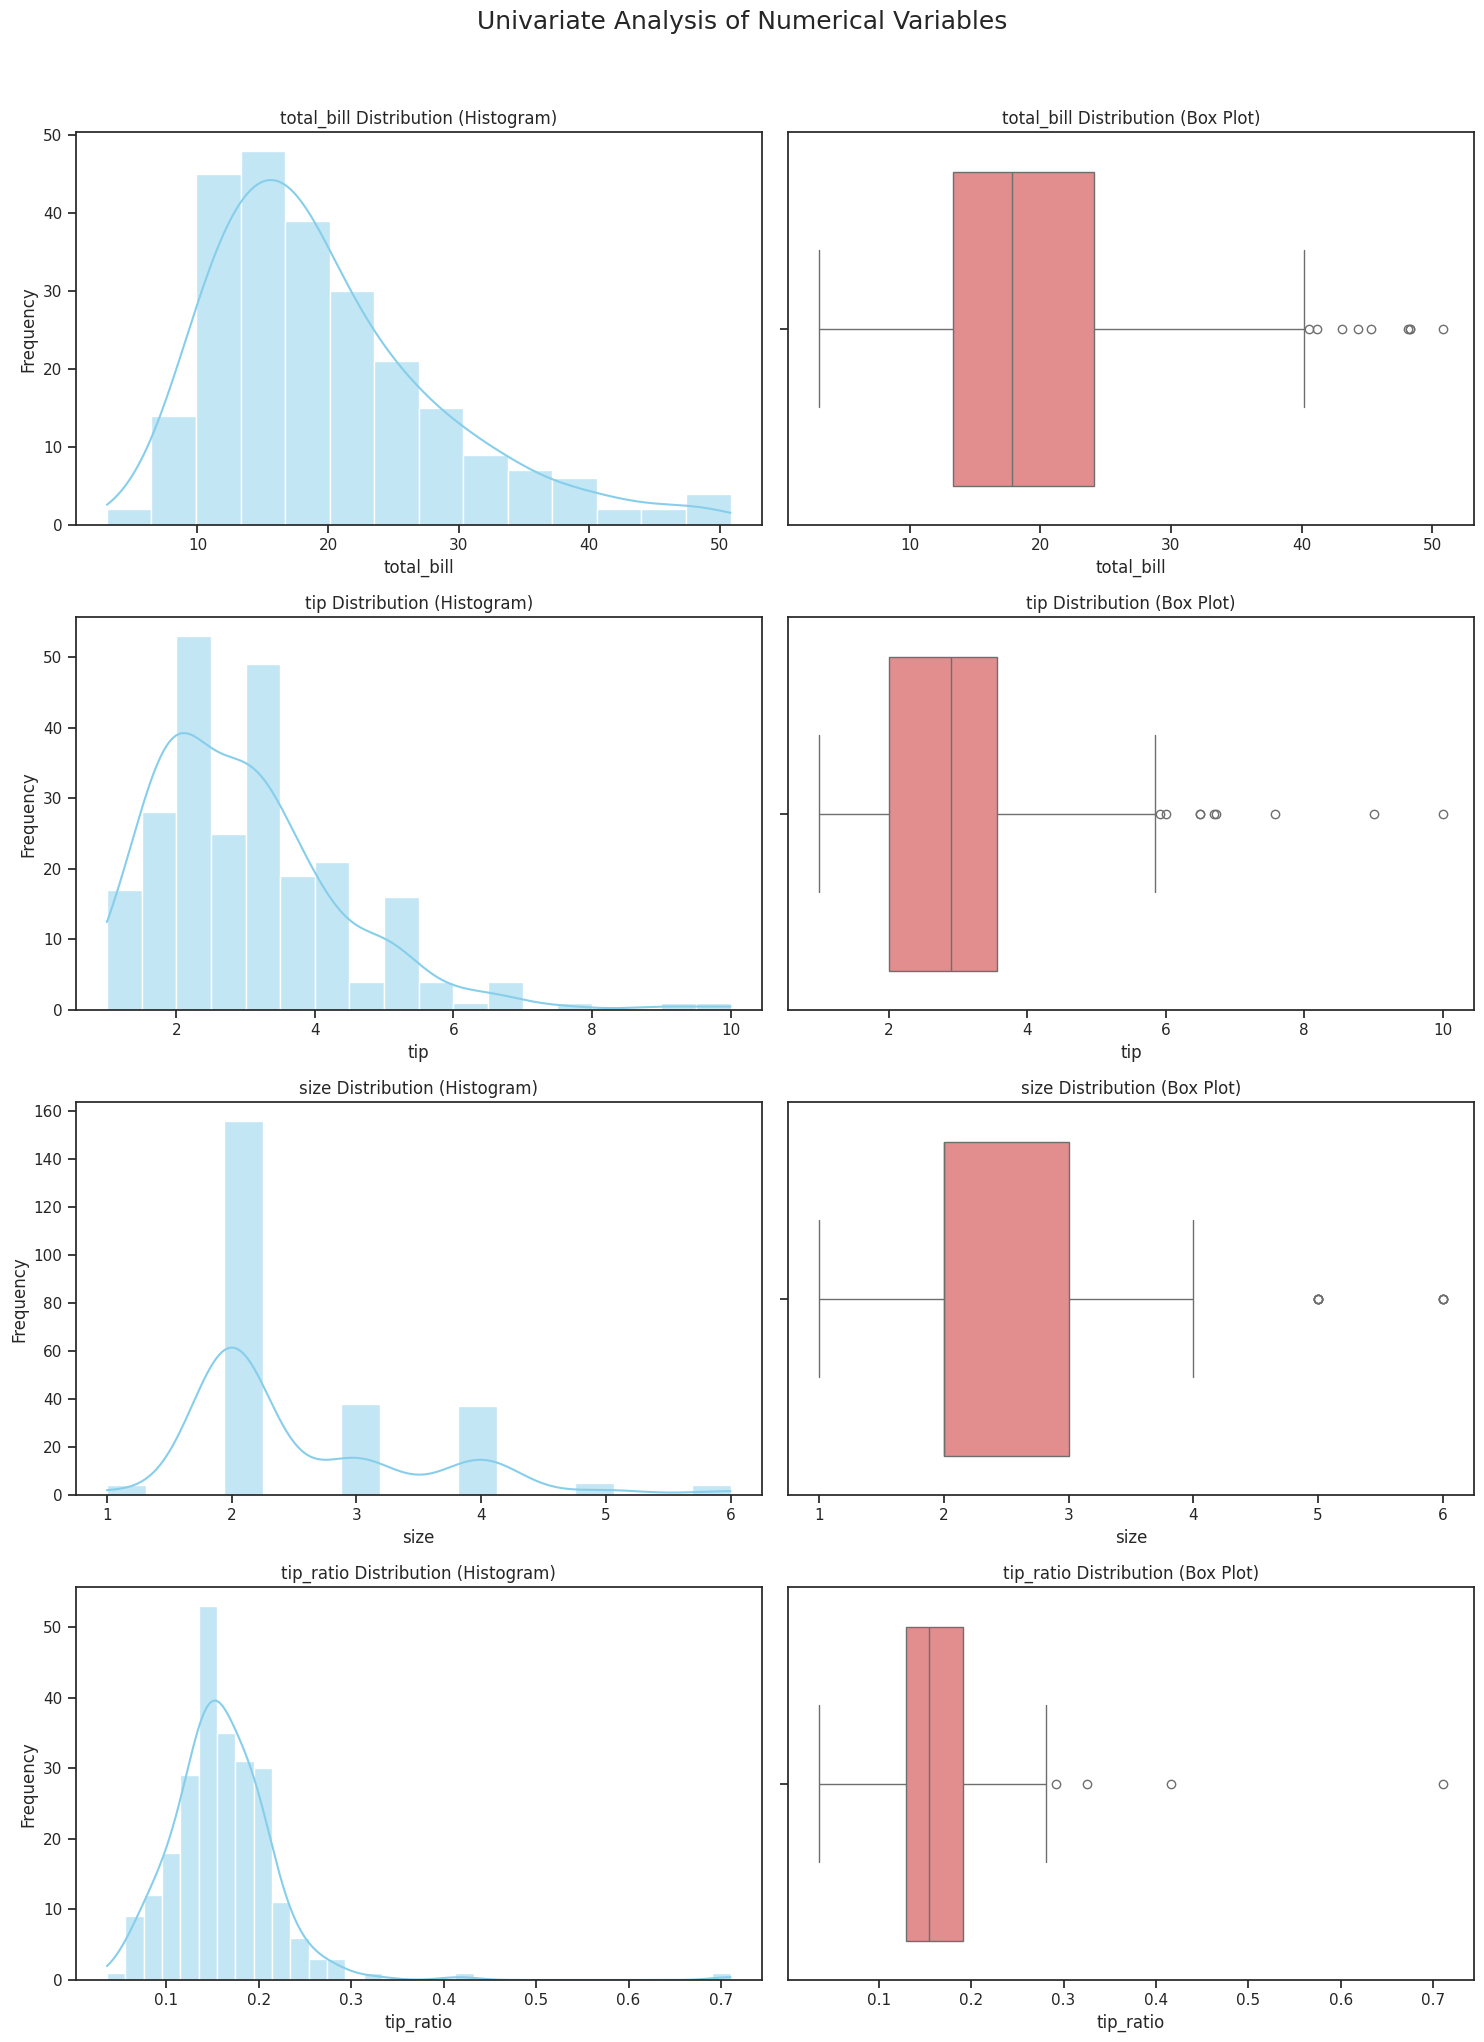

In [41]:
numerical_cols = ['total_bill', 'tip', 'size', 'tip_ratio']

fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(15, 5 * len(numerical_cols)))
fig.suptitle('Univariate Analysis of Numerical Variables', y=1.02, fontsize=18)

for i, col in enumerate(numerical_cols):
    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'{col} Distribution (Histogram)')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')

    # Box Plot
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'{col} Distribution (Box Plot)')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('')

plt.tight_layout()
plt.show()

#### 2.2 범주형 변수 (`sex`, `smoker`, `day`, `time`) 분석

각 범주형 변수의 카테고리별 빈도를 막대 그래프로 시각화합니다.

In [54]:
df.groupby('day')['tip'].describe()

/tmp/ipykernel_1645/3048255687.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('day')['tip'].describe()


,count,mean,std,min,25%,50%,75%,max
day,,,,,,,,
Thur,62.0,2.771452,1.240223,1.25,2.0000,2.305,3.3625,6.70
Fri,19.0,2.734737,1.019577,1.00,1.9600,3.000,3.3650,4.73
Sat,87.0,2.993103,1.631014,1.00,2.0000,2.750,3.3700,10.00
Sun,76.0,3.255132,1.234880,1.01,2.0375,3.150,4.0000,6.50


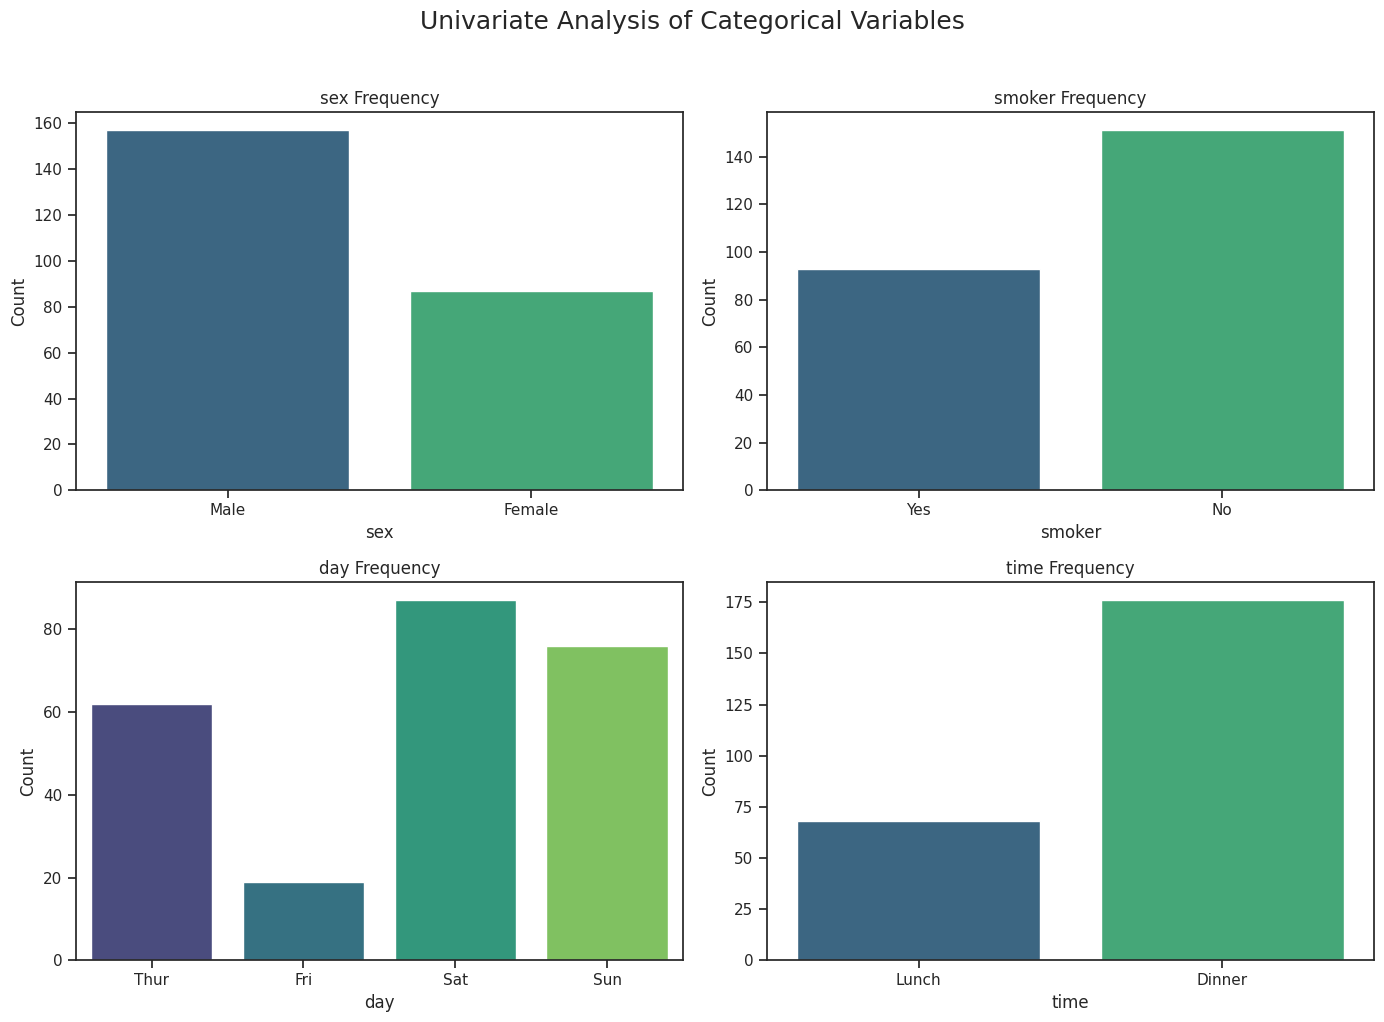

In [48]:
categorical_cols = ['sex', 'smoker', 'day', 'time']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Univariate Analysis of Categorical Variables', y=1.02, fontsize=18)

for i, col in enumerate(categorical_cols):
    row = i // 2
    col_idx = i % 2
    sns.countplot(x=df[col], ax=axes[row, col_idx], palette='viridis', hue=df[col], legend=False)
    axes[row, col_idx].set_title(f'{col} Frequency')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Count')

plt.tight_layout()
plt.show()

### 3. 다중 변수 분석 (Bivariate/Multivariate Analysis)

이제 여러 변수 간의 관계를 탐색하여 데이터 내의 패턴과 영향을 분석합니다.

#### 3.1 `total_bill`과 `tip` 간의 관계

`total_bill`과 `tip` 사이의 관계를 산점도로 시각화하고, `smoker`, `time`, `size`와 같은 다른 변수들을 고려하여 복합적인 관계를 파악합니다.

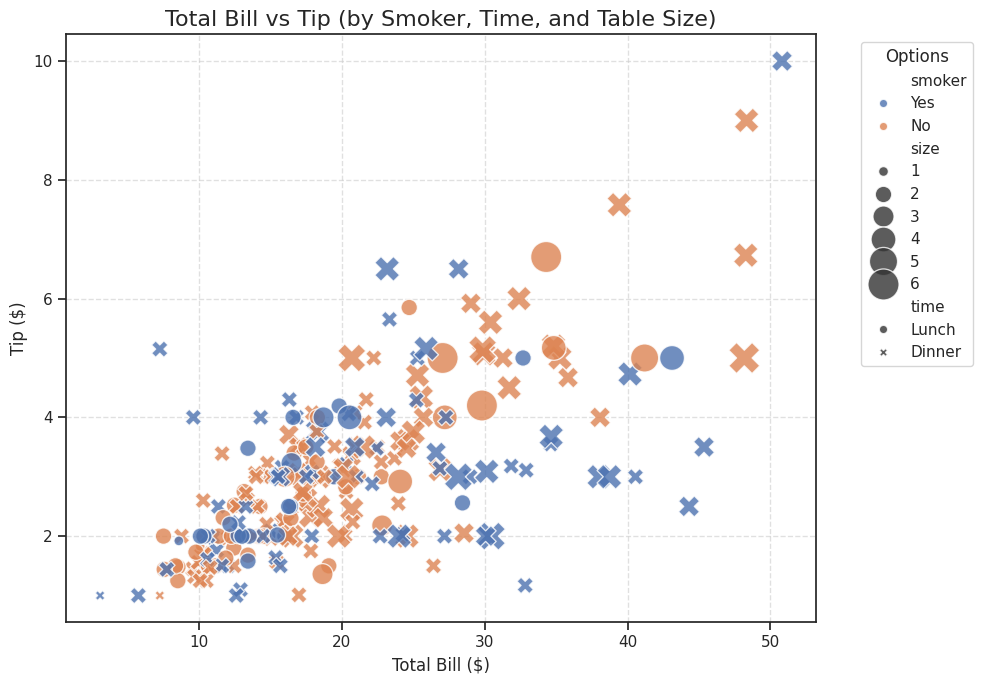

In [43]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='total_bill', y='tip', data=df, hue='smoker', style='time', size='size', sizes=(50, 500), palette='deep', alpha=0.8)
plt.title('Total Bill vs Tip (by Smoker, Time, and Table Size)', fontsize=16)
plt.xlabel('Total Bill ($)', fontsize=12)
plt.ylabel('Tip ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Options', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### 3.2 범주형 변수와 수치형 변수 간의 관계

요일(`day`), 시간(`time`), 성별(`sex`), 흡연 여부(`smoker`)와 `total_bill` 및 `tip` 간의 관계를 박스 플롯으로 비교합니다.

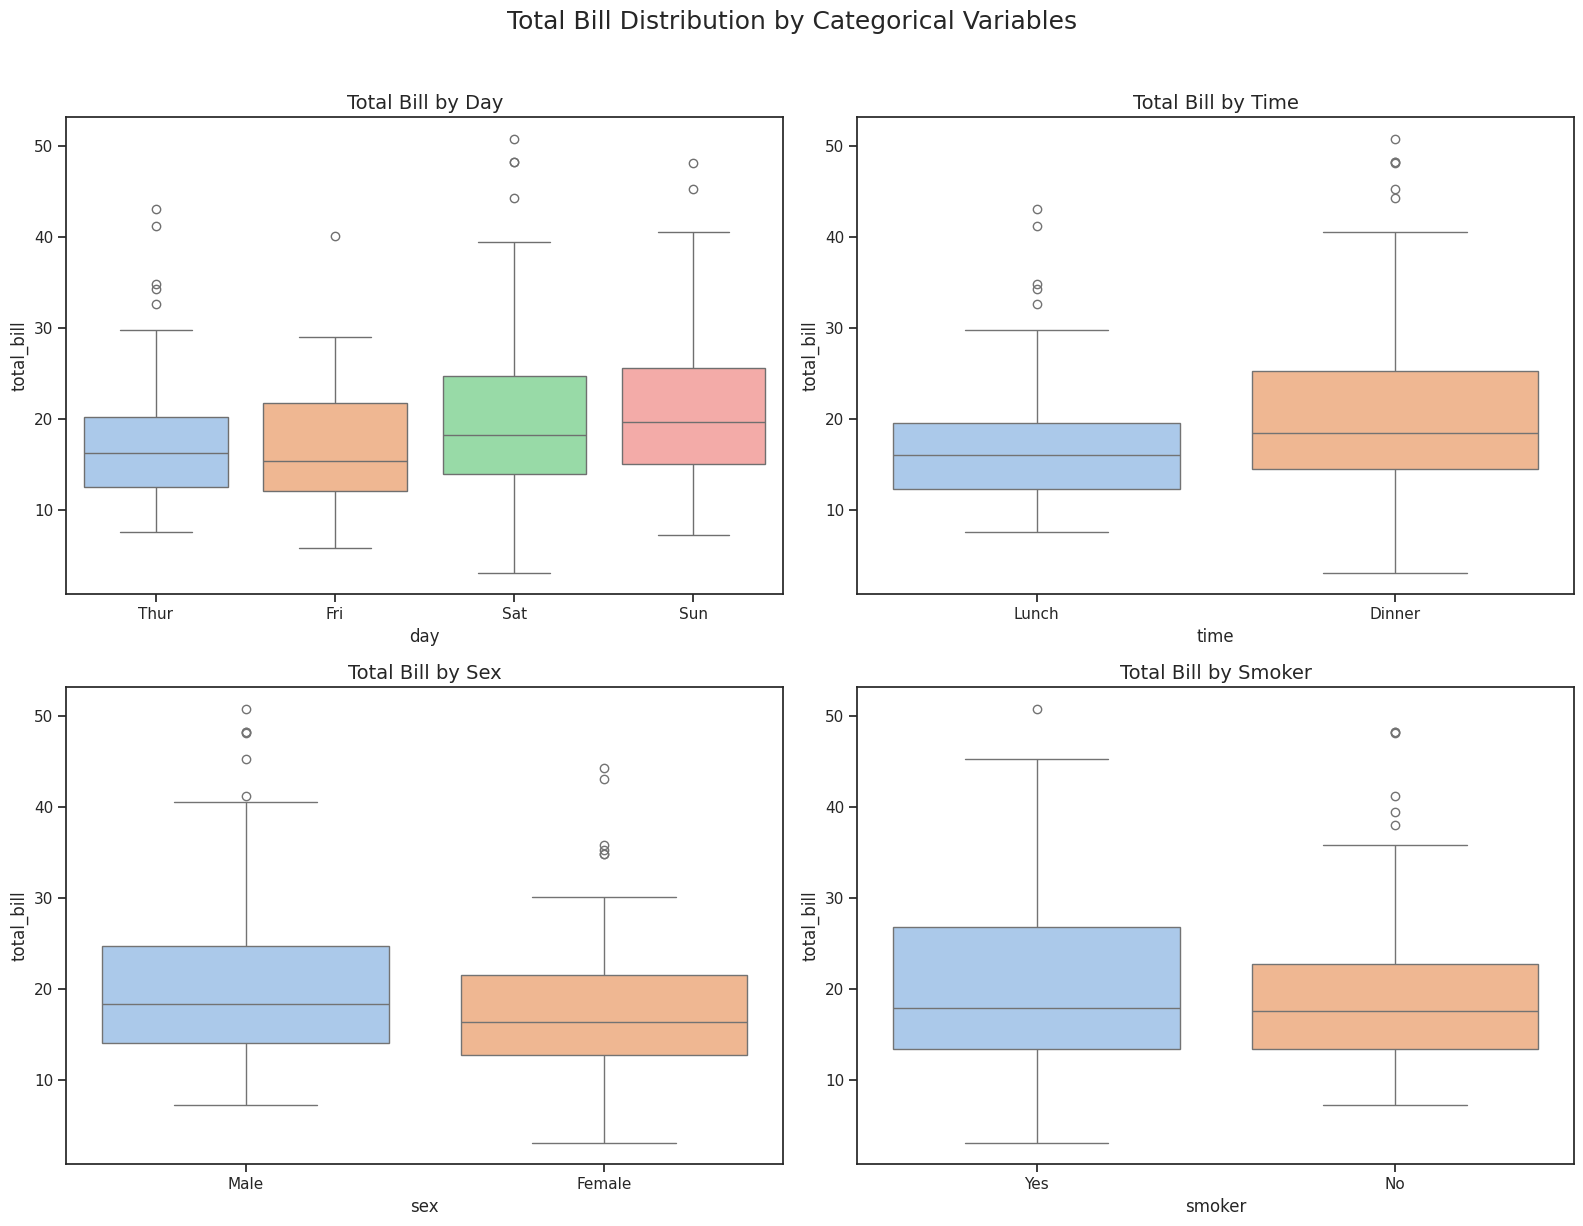

In [49]:
# 범주형 변수에 따른 total_bill 분포
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
fig.suptitle('Total Bill Distribution by Categorical Variables', y=1.02, fontsize=18)

sns.boxplot(x='day', y='total_bill', data=df, ax=axes[0, 0], palette='pastel', hue='day', legend=False)
axes[0, 0].set_title('Total Bill by Day', fontsize=14)

sns.boxplot(x='time', y='total_bill', data=df, ax=axes[0, 1], palette='pastel', hue='time', legend=False)
axes[0, 1].set_title('Total Bill by Time', fontsize=14)

sns.boxplot(x='sex', y='total_bill', data=df, ax=axes[1, 0], palette='pastel', hue='sex', legend=False)
axes[1, 0].set_title('Total Bill by Sex', fontsize=14)

sns.boxplot(x='smoker', y='total_bill', data=df, ax=axes[1, 1], palette='pastel', hue='smoker', legend=False)
axes[1, 1].set_title('Total Bill by Smoker', fontsize=14)

plt.tight_layout()
plt.show()

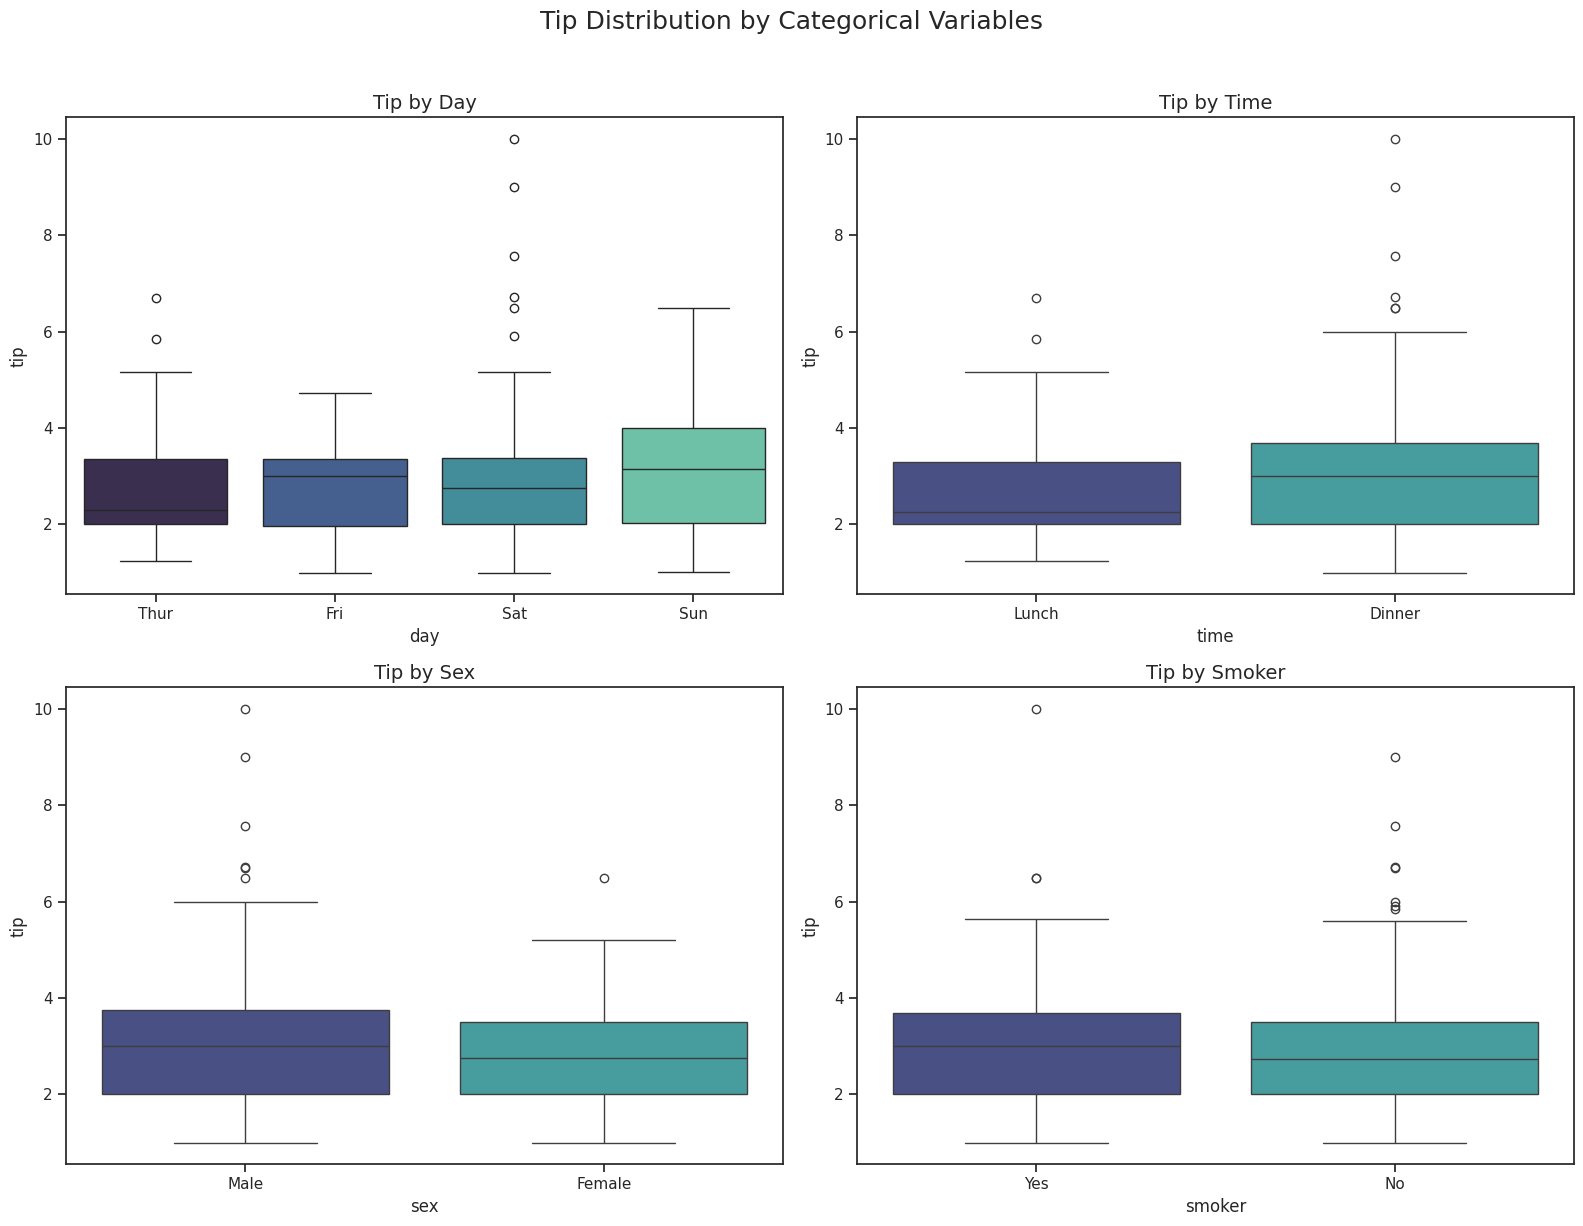

In [50]:
# 범주형 변수에 따른 tip 분포
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
fig.suptitle('Tip Distribution by Categorical Variables', y=1.02, fontsize=18)

sns.boxplot(x='day', y='tip', data=df, ax=axes[0, 0], palette='mako', hue='day', legend=False)
axes[0, 0].set_title('Tip by Day', fontsize=14)

sns.boxplot(x='time', y='tip', data=df, ax=axes[0, 1], palette='mako', hue='time', legend=False)
axes[0, 1].set_title('Tip by Time', fontsize=14)

sns.boxplot(x='sex', y='tip', data=df, ax=axes[1, 0], palette='mako', hue='sex', legend=False)
axes[1, 0].set_title('Tip by Sex', fontsize=14)

sns.boxplot(x='smoker', y='tip', data=df, ax=axes[1, 1], palette='mako', hue='smoker', legend=False)
axes[1, 1].set_title('Tip by Smoker', fontsize=14)

plt.tight_layout()
plt.show()

In [70]:
df = tips.copy() # df를 다시 tips 데이터셋으로 설정

# 요일(`day`)과 시간대(`time`)별 팁(`tip`)의 통계적 요약
day_time_tip_summary = df.groupby(['day', 'time'])['tip'].describe()
display(day_time_tip_summary)

# 평균 팁이 가장 높은 조합 찾기
max_tip_mean = day_time_tip_summary.loc[day_time_tip_summary['mean'].idxmax()]
print(f"\n평균 팁이 가장 높은 조합:\n{max_tip_mean.name} (평균: {max_tip_mean['mean']:.2f})")


/tmp/ipykernel_1645/1405802782.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_time_tip_summary = df.groupby(['day', 'time'])['tip'].describe()


count      mean       std   min     25%   50%    75%    max
day  time                                                               
Thur Lunch    61.0  2.767705  1.250162  1.25  2.0000  2.30  3.400   6.70
     Dinner    1.0  3.000000       NaN  3.00  3.0000  3.00  3.000   3.00
Fri  Lunch     7.0  2.382857  0.662966  1.58  1.9600  2.20  2.750   3.48
     Dinner   12.0  2.940000  1.156098  1.00  2.2500  3.00  3.625   4.73
Sat  Dinner   87.0  2.993103  1.631014  1.00  2.0000  2.75  3.370  10.00
Sun  Dinner   76.0  3.255132  1.234880  1.01  2.0375  3.15  4.000   6.50


평균 팁이 가장 높은 조합:
('Sun', 'Dinner') (평균: 3.26)


#### 3.3 팁 비율 (`tip_ratio`)에 대한 추가 분석

팁 비율이 높은 경우를 필터링했으므로, 이 `df_high_tip` 데이터프레임을 활용하여 팁 비율이 20% 이상인 경우의 특징을 살펴봅니다. 예를 들어, 어떤 요일, 시간, 성별, 흡연 여부 그룹에서 팁 비율이 높은 경향을 보이는지 확인할 수 있습니다.

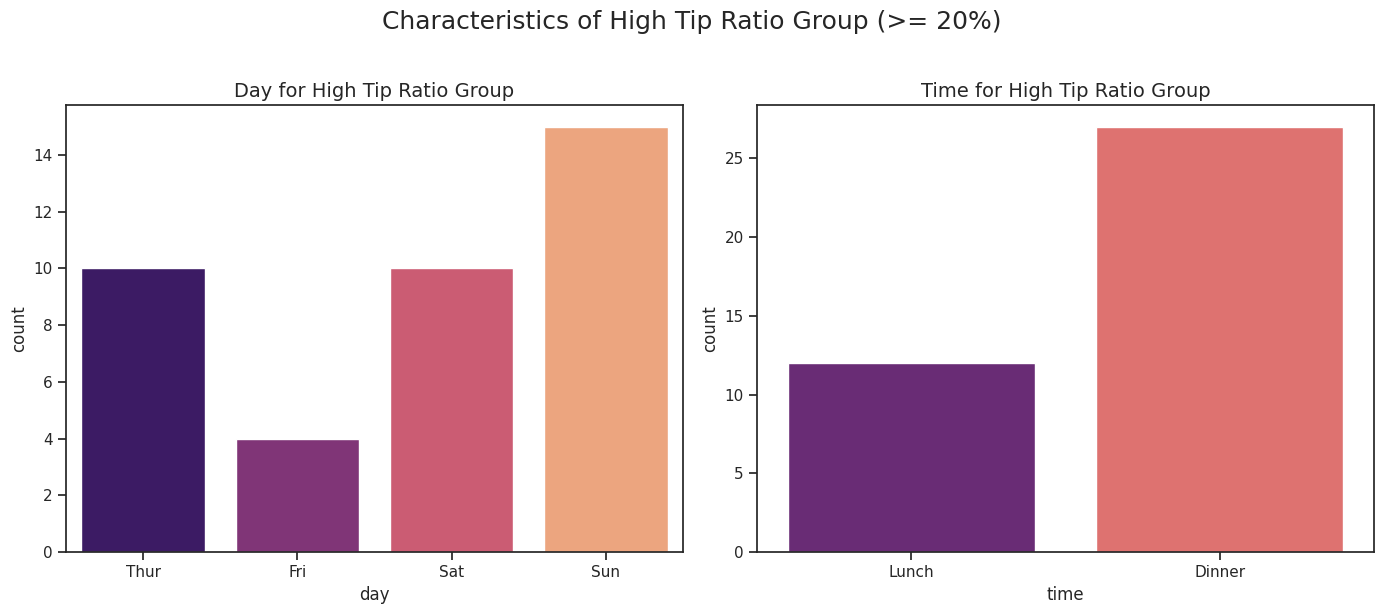

In [51]:
# 팁 비율이 높은 그룹 (20% 이상)의 요일별, 시간대별 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Characteristics of High Tip Ratio Group (>= 20%)', y=1.02, fontsize=18)

sns.countplot(x='day', data=df_high_tip, ax=axes[0], palette='magma', hue='day', legend=False)
axes[0].set_title('Day for High Tip Ratio Group', fontsize=14)

sns.countplot(x='time', data=df_high_tip, ax=axes[1], palette='magma', hue='time', legend=False)
axes[1].set_title('Time for High Tip Ratio Group', fontsize=14)

plt.tight_layout()
plt.show()

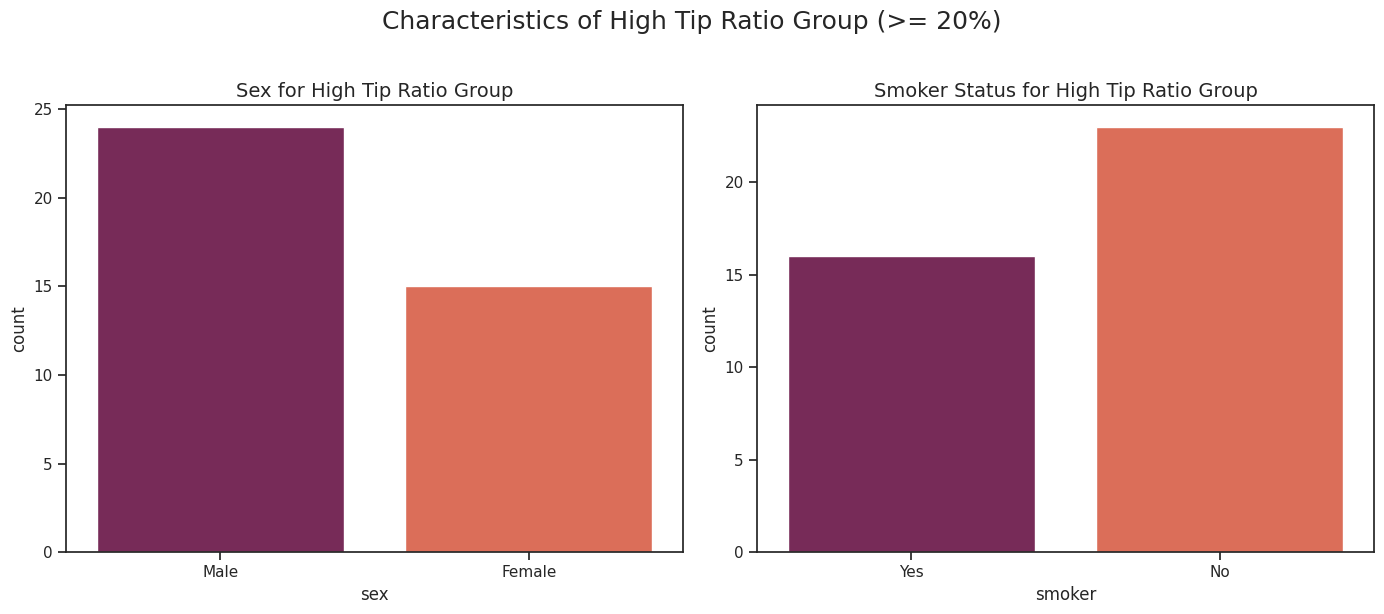

In [52]:
# 팁 비율이 높은 그룹 (20% 이상)의 성별, 흡연 여부 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Characteristics of High Tip Ratio Group (>= 20%)', y=1.02, fontsize=18)

sns.countplot(x='sex', data=df_high_tip, ax=axes[0], palette='rocket', hue='sex', legend=False)
axes[0].set_title('Sex for High Tip Ratio Group', fontsize=14)

sns.countplot(x='smoker', data=df_high_tip, ax=axes[1], palette='rocket', hue='smoker', legend=False)
axes[1].set_title('Smoker Status for High Tip Ratio Group', fontsize=14)

plt.tight_layout()
plt.show()

In [57]:
path = '/content/sample_data/california_housing_test.csv'

df = pd.read_csv(path)

df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

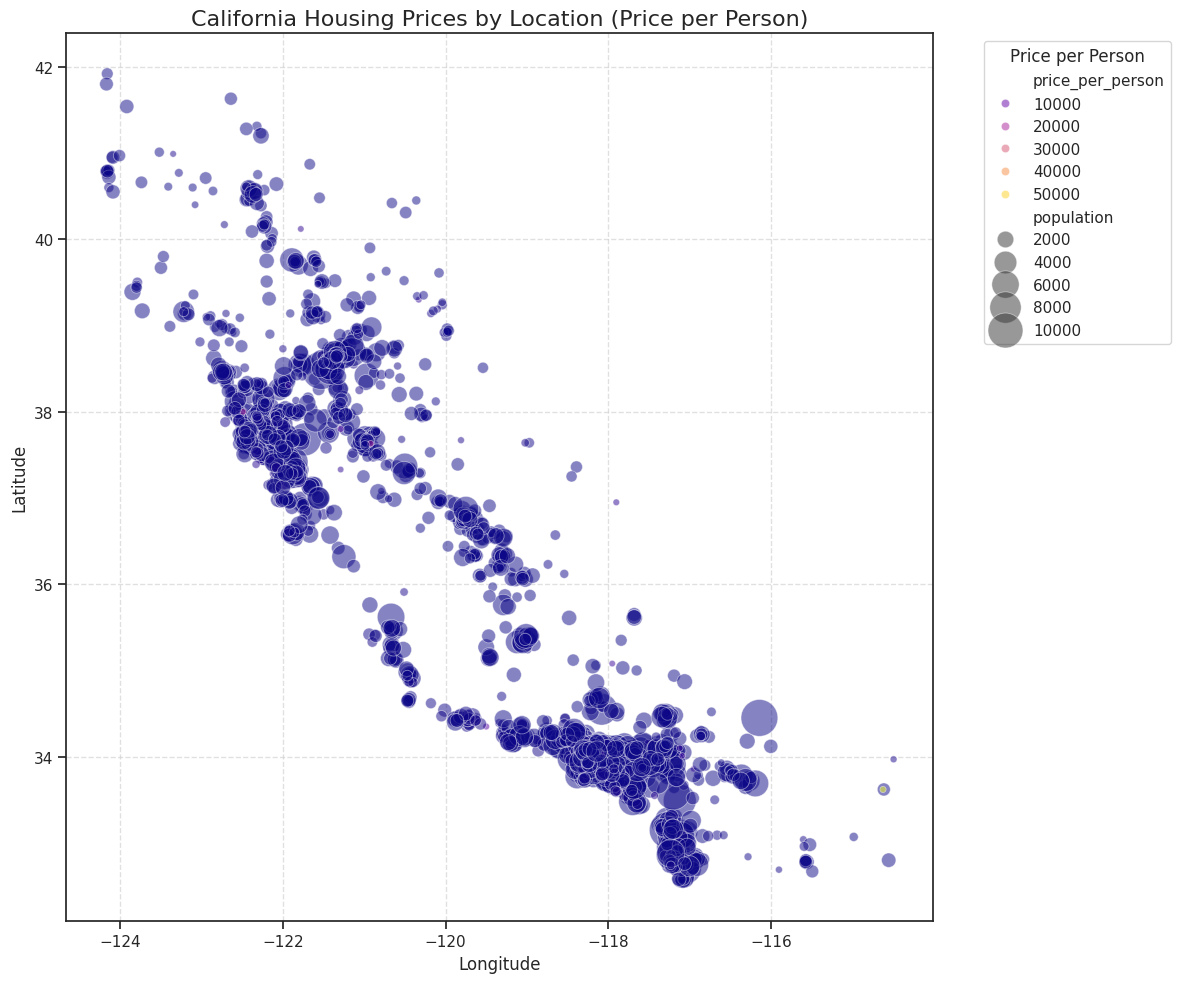

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# 'median_house_value'를 'population'으로 나누어 1인당 주택 가치 계산
df['price_per_person'] = df['median_house_value'] / df['population']

plt.figure(figsize=(12, 10))

# 지도를 scatter plot으로 시각화
# x축: longitude, y축: latitude
# c: color (price_per_person), s: size (population), alpha: 투명도
sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='price_per_person',
    size='population',
    sizes=(20, 750), # 점의 크기 범위 조정 (이전: 20, 2000)
    palette='plasma', # 팔레트를 'viridis'에서 'plasma'로 변경
    alpha=0.5
)

plt.title('California Housing Prices by Location (Price per Person)', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend(title='Price per Person', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

위 지도는 캘리포니아 주택 데이터에서 1인당 주택 가치를 기준으로 집값이 비싼 지역을 시각화한 것입니다.

*   **X축 (Longitude)**과 **Y축 (Latitude)**은 캘리포니아 내의 지리적 위치를 나타냅니다.
*   **색상 (Hue)**은 `median_house_value`를 `population`으로 나눈 값인 `price_per_person`을 나타냅니다. 이번에는 `plasma` 팔레트를 사용하여 낮은 값에서는 어두운 색상으로, 높은 값에서는 밝은 노란색에 가까운 색상으로 변화하여 색상 차이를 더 명확하게 볼 수 있습니다.
*   **점의 크기 (Size)**는 해당 지역의 `population` (인구)을 나타냅니다. 점이 클수록 인구가 많다는 것을 의미합니다.

수정된 지도에서 점의 크기 범위를 줄이고 `plasma` 팔레트를 사용하여 시각적 복잡성을 개선하고 색상 분류를 더 명확하게 했습니다. 대체적으로 해안가(특히 남부 캘리포니아)와 일부 대도시 주변 지역에서 1인당 주택 가치가 높게 나타나는 것을 확인할 수 있습니다. 인구가 많은 지역(큰 점)과 1인당 주택 가치가 높은 지역이 항상 일치하지는 않음을 알 수 있습니다.